# Zero Sales Handling

**Problem:** 81.8% of article-week combinations have zero sales (intermittent demand).  
This notebook implements two approaches recommended by the thesis supervisor:

1. **Even spreading** — redistribute monthly article sales evenly across all weeks in that month, smoothing out zero-week spikes.
2. **Binary demand occurrence (0/1 function)** — add a `demand_occurred` feature and implement a two-stage model: first classify whether any sales happen, then predict quantity.

Both variants are saved as ready-to-use train/val/test splits.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score, classification_report
import lightgbm as lgb
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
os.makedirs('plots/zero_sales', exist_ok=True)

BASE = '/Users/kamilaya/Desktop/thesis'

In [2]:
# Load the preprocessed full grid (unscaled)
df = pd.read_csv(f'{BASE}/tshirts_preprocessed.csv', parse_dates=['week_start'])
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Zero-sale weeks overall: {(df["weekly_sales_volume"] == 0).mean()*100:.1f}%')

Loaded: 834,538 rows × 113 columns
Zero-sale weeks overall: 81.8%


---
## Approach 1: Even Spreading

Instead of leaving zero-week entries as 0, aggregate each article's sales to the **monthly level** and redistribute evenly across all weeks of that month.  
This converts intermittent integer counts into smoothed fractional weekly averages, reducing the density of exact zeros.

**Formula:**  
`spread_sales(article, week) = monthly_total_sales(article, month) / weeks_in_month`

In [3]:
# ── Even Spreading ───────────────────────────────────────────────────────────

df_spread = df.copy()

# Count weeks per article per month
df_spread['year_month_dt'] = df_spread['week_start'].dt.to_period('M').astype(str)

# Monthly total sales per article
monthly_sales = (
    df_spread
    .groupby(['article_id', 'year_month_dt'])['weekly_sales_volume']
    .sum()
    .reset_index()
    .rename(columns={'weekly_sales_volume': 'monthly_total'})
)

# Number of weeks per article per month in dataset
weeks_per_month = (
    df_spread
    .groupby(['article_id', 'year_month_dt'])['week_start']
    .count()
    .reset_index()
    .rename(columns={'week_start': 'n_weeks'})
)

monthly_sales = monthly_sales.merge(weeks_per_month, on=['article_id', 'year_month_dt'])
monthly_sales['spread_sales'] = monthly_sales['monthly_total'] / monthly_sales['n_weeks']

# Merge back
df_spread = df_spread.merge(
    monthly_sales[['article_id', 'year_month_dt', 'spread_sales']],
    on=['article_id', 'year_month_dt'], how='left'
)

zero_after = (df_spread['spread_sales'] == 0).mean() * 100
print(f'Zero-sale weeks after even spreading: {zero_after:.1f}%')
print(f'Spread sales stats:\n{df_spread["spread_sales"].describe().round(3)}')

Zero-sale weeks after even spreading: 72.5%
Spread sales stats:
count    834538.000
mean          2.467
std          11.488
min           0.000
25%           0.000
50%           0.000
75%           0.250
max         164.000
Name: spread_sales, dtype: float64


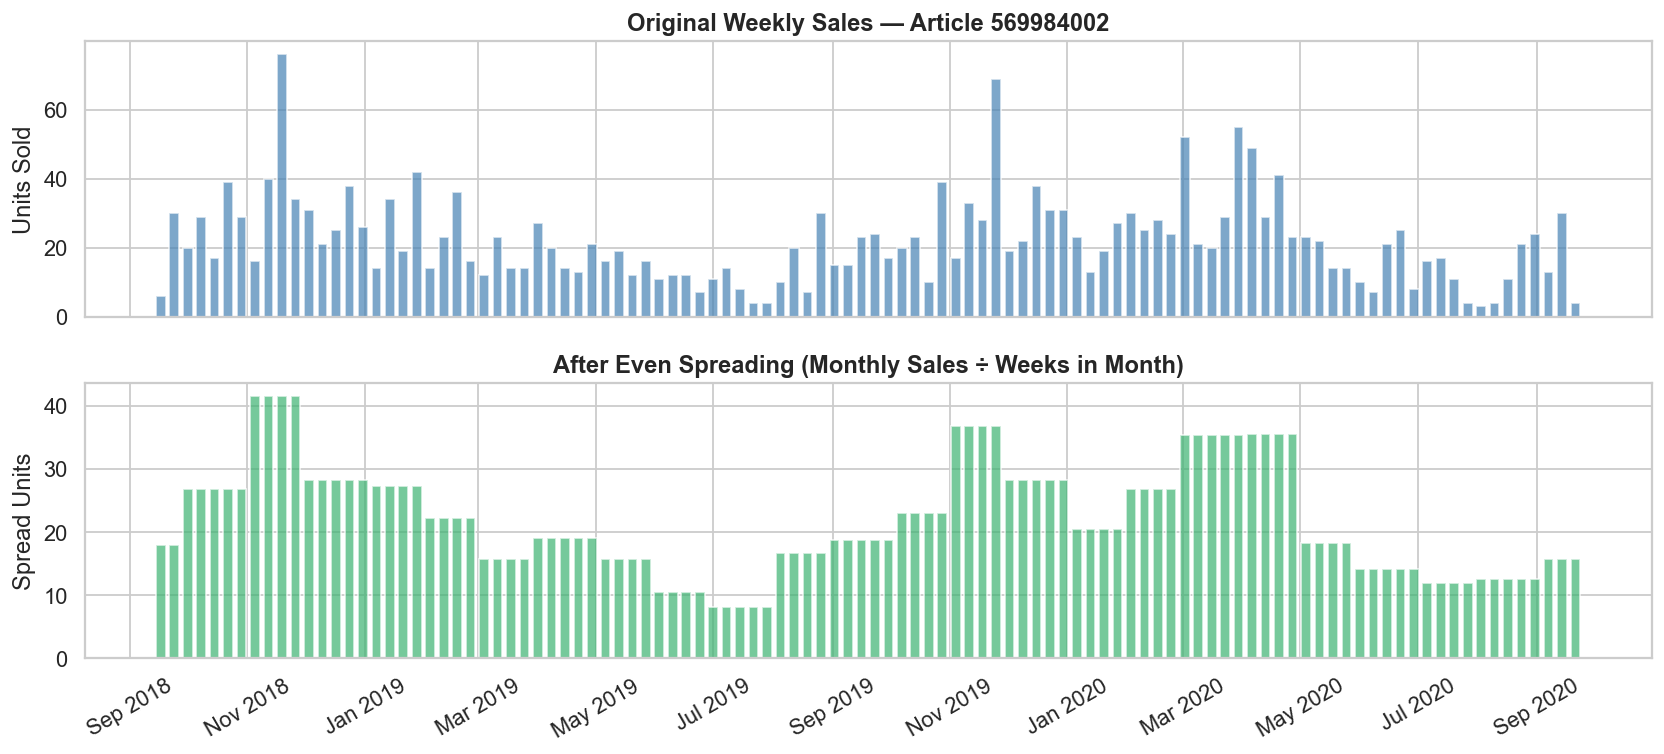

Saved: plots/zero_sales/approach1_even_spread_example.png


In [4]:
# Compare original vs spread distributions for a sample article
sample_article = df_spread[df_spread['weekly_sales_volume'] > 0]['article_id'].value_counts().index[5]
sample = df_spread[df_spread['article_id'] == sample_article].sort_values('week_start')

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].bar(sample['week_start'], sample['weekly_sales_volume'],
            color='steelblue', alpha=0.7, width=5)
axes[0].set_title(f'Original Weekly Sales — Article {sample_article}', fontweight='bold')
axes[0].set_ylabel('Units Sold')

axes[1].bar(sample['week_start'], sample['spread_sales'],
            color='mediumseagreen', alpha=0.7, width=5)
axes[1].set_title('After Even Spreading (Monthly Sales ÷ Weeks in Month)', fontweight='bold')
axes[1].set_ylabel('Spread Units')

import matplotlib.dates as mdates
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plots/zero_sales/approach1_even_spread_example.png')
plt.show()
print('Saved: plots/zero_sales/approach1_even_spread_example.png')

In [5]:
# Replace target with spread sales and re-log-transform
df_spread['weekly_sales_volume_original'] = df_spread['weekly_sales_volume'].copy()
df_spread['weekly_sales_volume']          = df_spread['spread_sales']
df_spread['log_sales_volume']             = np.log1p(df_spread['weekly_sales_volume'])

zero_spread = (df_spread['weekly_sales_volume'] == 0).mean() * 100
print(f'Remaining exact zeros after spreading: {zero_spread:.1f}%')
print(f'log_sales_volume stats:\n{df_spread["log_sales_volume"].describe().round(3)}')

Remaining exact zeros after spreading: 72.5%
log_sales_volume stats:
count    834538.000
mean          0.374
std           0.871
min           0.000
25%           0.000
50%           0.000
75%           0.223
max           5.106
Name: log_sales_volume, dtype: float64


In [6]:
# Save spread dataset
df_spread.drop(columns=['year_month_dt', 'spread_sales'], inplace=True)
df_spread.to_csv(f'{BASE}/tshirts_spread.csv', index=False)
print('Saved: tshirts_spread.csv')

# Time-based splits
TRAIN_END, VAL_END = '2019-04-30', '2019-12-31'
train_s = df_spread[df_spread['week_start'] <= TRAIN_END].copy()
val_s   = df_spread[(df_spread['week_start'] > TRAIN_END) & (df_spread['week_start'] <= VAL_END)].copy()
test_s  = df_spread[df_spread['week_start'] > VAL_END].copy()

train_s.to_csv(f'{BASE}/tshirts_spread_train.csv', index=False)
val_s.to_csv(f'{BASE}/tshirts_spread_val.csv',     index=False)
test_s.to_csv(f'{BASE}/tshirts_spread_test.csv',   index=False)
print(f'Saved spread splits:  train={len(train_s):,}  val={len(val_s):,}  test={len(test_s):,}')

Saved: tshirts_spread.csv
Saved spread splits:  train=259,809  val=275,555  test=299,174


### Pre-Defense Discussion: Why Even Spreading?

At the pre-defense the committee raised the question:
> *"If you spread monthly sales evenly across weeks and the model learns to predict
> that smoothed signal, aren't you just predicting the monthly mean — which is circular?"*

**Why even spreading is used (and what it actually does):**

1. **Training-time regularisation for intermittent demand.**  
   Without spreading, 81.8 % of article-weeks are exact zeros with sporadic non-zero spikes.  
   Lag features built from this binary signal carry very little information.  
   Spreading converts `[0, 0, 8, 0]` → `[2, 2, 2, 2]`, giving lag features a stable,
   non-zero signal that the model can learn from.

2. **Monthly totals are preserved exactly.**  
   The operation is `spread = monthly_total / weeks_in_month`. No information is lost;
   the same number of units is allocated, just smoothed across the month.

3. **It is not the same as predicting the monthly mean directly.**  
   The model sees article-level features (price, age, lag patterns) alongside the spread
   target and learns cross-article patterns — something a simple monthly mean cannot do.

**Acknowledged limitation:**  
Training on spread sales and evaluating against the *same* spread targets is a softer
test than evaluating against original weekly sales. To address this, the cell below
re-evaluates the spread-trained LightGBM model against **original weekly sales**, making
it directly comparable to the baseline results in `baselines.ipynb`.

In [ ]:
# ── Cross-evaluation: spread-trained model vs. ORIGINAL weekly sales ─────────
# Trains LightGBM on even-spread targets, then evaluates on the original
# weekly_sales_volume (not the smoothed spread target).
# This is the fair apples-to-apples comparison with baselines.ipynb.

from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb

def rmse(a, b):    return np.sqrt(mean_squared_error(a, b))
def nz_mape(a, b):
    a, b = np.asarray(a), np.asarray(b)
    mask = a > 0
    return np.mean(np.abs((a[mask] - b[mask]) / a[mask])) * 100 if mask.sum() else np.nan

TRAIN_END, VAL_END = '2019-04-30', '2019-12-31'

OHE_COLS = [c for c in df_spread.columns if any(
    c.startswith(p) for p in [
        'index_group_name_', 'colour_group_name_',
        'graphical_appearance_name_', 'perceived_colour_value_name_'
    ]
)]

SPREAD_FEATURES = [
    'avg_weekly_price', 'real_price', 'price_vs_median',
    'week_of_year', 'month', 'quarter',
    'is_spring_summer', 'is_sale_season',
    'product_age_weeks',
    'sales_lag1', 'sales_lag2', 'sales_lag4',
    'sales_rolling4_mean', 'sales_rolling4_std',
] + OHE_COLS

if 'covid' in df_spread.columns:
    SPREAD_FEATURES = ['covid'] + SPREAD_FEATURES

SPREAD_FEATURES = [f for f in SPREAD_FEATURES if f in df_spread.columns]

tr = df_spread[df_spread['week_start'] <= TRAIN_END].copy()
va = df_spread[(df_spread['week_start'] > TRAIN_END) & (df_spread['week_start'] <= VAL_END)].copy()
te = df_spread[df_spread['week_start'] > VAL_END].copy()

# Target is the spread (smoothed) log-sales — same as the saved splits
TARGET_SPREAD = 'log_sales_volume'
# Original sales for cross-evaluation
ORIG_COL = 'weekly_sales_volume_original'

X_tr = tr[SPREAD_FEATURES];  y_tr = tr[TARGET_SPREAD]
X_va = va[SPREAD_FEATURES];  y_va = va[TARGET_SPREAD]
X_te = te[SPREAD_FEATURES]

spread_lgbm = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
spread_lgbm.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)

# Predictions back to original scale
val_pred_raw  = np.expm1(np.clip(spread_lgbm.predict(X_va), 0, None))
test_pred_raw = np.expm1(np.clip(spread_lgbm.predict(X_te), 0, None))

# ── Evaluate on SPREAD targets (internal) ─────────────────────────────────
va_spread_actual  = np.expm1(va[TARGET_SPREAD].values)
te_spread_actual  = np.expm1(te[TARGET_SPREAD].values)

print('=' * 65)
print('LightGBM trained on SPREAD targets')
print('=' * 65)
print('\nEvaluated vs. SPREAD targets (softer test):')
print(f'  Val   RMSE={rmse(va_spread_actual, val_pred_raw):.4f}  '
      f'MAE={mean_absolute_error(va_spread_actual, val_pred_raw):.4f}  '
      f'NZ-MAPE={nz_mape(va_spread_actual, val_pred_raw):.1f}%')
print(f'  Test  RMSE={rmse(te_spread_actual, test_pred_raw):.4f}  '
      f'MAE={mean_absolute_error(te_spread_actual, test_pred_raw):.4f}  '
      f'NZ-MAPE={nz_mape(te_spread_actual, test_pred_raw):.1f}%')

# ── Cross-evaluate on ORIGINAL weekly sales (fair comparison) ────────────
if ORIG_COL in va.columns and ORIG_COL in te.columns:
    va_orig_actual = va[ORIG_COL].values
    te_orig_actual = te[ORIG_COL].values

    print('\nEvaluated vs. ORIGINAL weekly sales (fair, apples-to-apples):')
    print(f'  Val   RMSE={rmse(va_orig_actual, val_pred_raw):.4f}  '
          f'MAE={mean_absolute_error(va_orig_actual, val_pred_raw):.4f}  '
          f'NZ-MAPE={nz_mape(va_orig_actual, val_pred_raw):.1f}%')
    print(f'  Test  RMSE={rmse(te_orig_actual, test_pred_raw):.4f}  '
          f'MAE={mean_absolute_error(te_orig_actual, test_pred_raw):.4f}  '
          f'NZ-MAPE={nz_mape(te_orig_actual, test_pred_raw):.1f}%')
    print()
    print('  Reference (models.ipynb, LightGBM baseline, no spread):')
    print('    Val  RMSE=5.2051  Test RMSE=6.2436  (NZ-MAPE ~59–69%)')
    print()
    print('  Interpretation:')
    print('  A spread-trained model tested on original sales will generally show')
    print('  higher RMSE than the spread-target RMSE, because it was regularised')
    print('  toward smooth monthly averages, not toward weekly spikes.')
    print('  The comparison reveals the trade-off: spreading reduces training noise')
    print('  but produces a model optimised for smooth, not volatile, demand.')
else:
    print('\n[SKIP] weekly_sales_volume_original column not found in split data.')
    print('  Re-run zs_006 first to generate df_spread with the original column.')

---
## Approach 2: Binary Demand Occurrence Function (0/1)

Adds a `demand_occurred` column: **1** if weekly_sales_volume > 0, **0** otherwise.  
This enables a **two-stage modeling** strategy:

- **Stage 1 (classifier):** Predict whether demand will occur at all → `demand_occurred ∈ {0, 1}`
- **Stage 2 (regressor):** For weeks where demand is predicted ≥ 1, predict the actual quantity

The binary flag also serves as an additional feature for the single-stage regression models.

In [7]:
# ── Binary Occurrence Feature ────────────────────────────────────────────────

df_binary = df.copy()

# Binary occurrence label
df_binary['demand_occurred'] = (df_binary['weekly_sales_volume'] > 0).astype(int)

# Lagged occurrence features (did demand happen last week / last 4 weeks?)
grp = df_binary.groupby('article_id')['demand_occurred']
df_binary['demand_lag1']        = grp.shift(1).fillna(0).astype(int)
df_binary['demand_rolling4_pct'] = grp.transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).mean()
).fillna(0)

print(f'Class balance for demand_occurred:')
vc = df_binary['demand_occurred'].value_counts(normalize=True) * 100
print(f'  0 (no demand): {vc[0]:.1f}%')
print(f'  1 (demand):    {vc[1]:.1f}%')

Class balance for demand_occurred:
  0 (no demand): 81.8%
  1 (demand):    18.2%


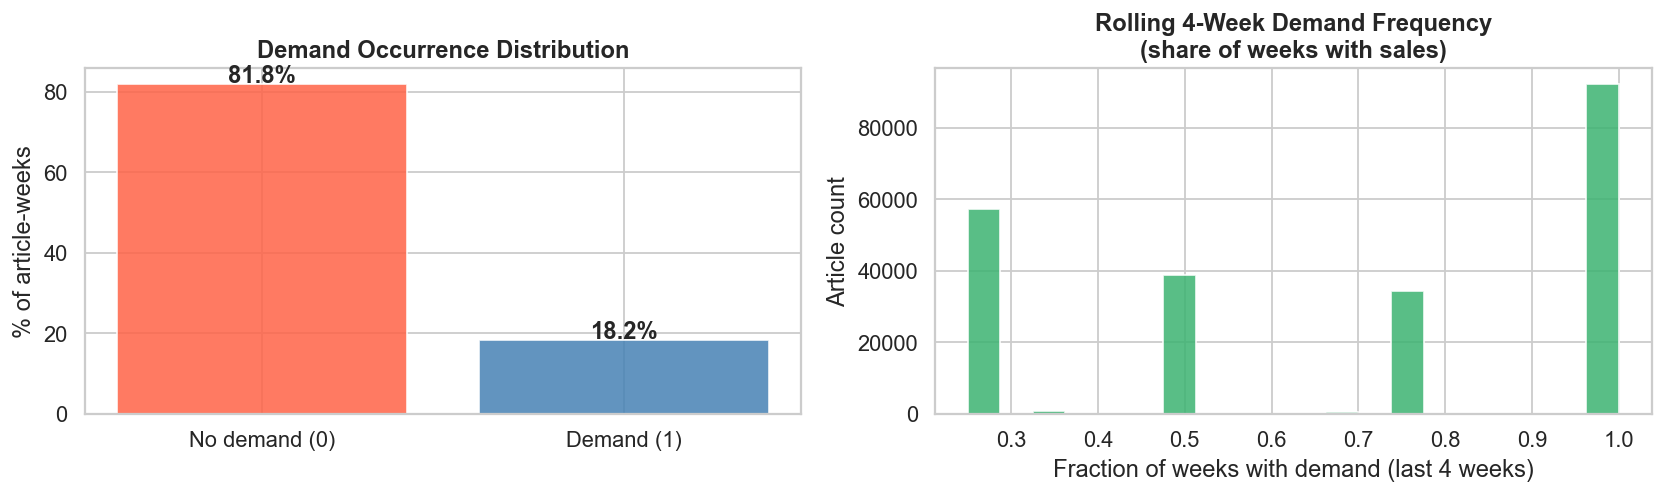

Saved: plots/zero_sales/approach2_demand_occurrence.png


In [8]:
# Plot demand_rolling4_pct distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar([0, 1],
            [vc[0], vc[1]],
            color=['tomato', 'steelblue'], edgecolor='white', alpha=0.85)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No demand (0)', 'Demand (1)'])
axes[0].set_ylabel('% of article-weeks')
axes[0].set_title('Demand Occurrence Distribution', fontweight='bold')
for i, v in enumerate([vc[0], vc[1]]):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].hist(df_binary[df_binary['demand_rolling4_pct'] > 0]['demand_rolling4_pct'],
             bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Rolling 4-Week Demand Frequency\n(share of weeks with sales)', fontweight='bold')
axes[1].set_xlabel('Fraction of weeks with demand (last 4 weeks)')
axes[1].set_ylabel('Article count')

plt.tight_layout()
plt.savefig('plots/zero_sales/approach2_demand_occurrence.png')
plt.show()
print('Saved: plots/zero_sales/approach2_demand_occurrence.png')

In [9]:
# ── Stage 1: Train demand occurrence classifier ──────────────────────────────

TRAIN_END, VAL_END = '2019-04-30', '2019-12-31'
train_b = df_binary[df_binary['week_start'] <= TRAIN_END].copy()
val_b   = df_binary[(df_binary['week_start'] > TRAIN_END) & (df_binary['week_start'] <= VAL_END)].copy()
test_b  = df_binary[df_binary['week_start'] > VAL_END].copy()

OHE_COLS = [c for c in df_binary.columns if any(
    c.startswith(p) for p in [
        'index_group_name_', 'colour_group_name_',
        'graphical_appearance_name_', 'perceived_colour_value_name_'
    ]
)]

CLASSIFIER_FEATURES = [
    'avg_weekly_price', 'real_price', 'price_vs_median',
    'week_of_year', 'month', 'quarter',
    'is_spring_summer', 'is_sale_season',
    'product_age_weeks',
    'demand_lag1', 'demand_rolling4_pct',
    'sales_lag1', 'sales_lag2', 'sales_lag4',
    'sales_rolling4_mean', 'sales_rolling4_std',
] + OHE_COLS

# Add covid if available
if 'covid' in df_binary.columns:
    CLASSIFIER_FEATURES = ['covid'] + CLASSIFIER_FEATURES

CLASSIFIER_FEATURES = [f for f in CLASSIFIER_FEATURES if f in train_b.columns]

X_tr = train_b[CLASSIFIER_FEATURES]; y_tr = train_b['demand_occurred']
X_va = val_b[CLASSIFIER_FEATURES];   y_va = val_b['demand_occurred']
X_te = test_b[CLASSIFIER_FEATURES];  y_te = test_b['demand_occurred']

clf = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced',  # handle class imbalance (82% zeros)
    random_state=42, verbose=-1
)
clf.fit(X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)])

val_pred_cls  = clf.predict(X_va)
test_pred_cls = clf.predict(X_te)

print('Stage 1 — Demand Occurrence Classifier')
print('\nValidation set:')
print(classification_report(y_va, val_pred_cls, target_names=['No demand', 'Demand']))
print('\nTest set:')
print(classification_report(y_te, test_pred_cls, target_names=['No demand', 'Demand']))

Stage 1 — Demand Occurrence Classifier

Validation set:
              precision    recall  f1-score   support

   No demand       0.99      0.98      0.99    226089
      Demand       0.93      0.97      0.95     49466

    accuracy                           0.98    275555
   macro avg       0.96      0.98      0.97    275555
weighted avg       0.98      0.98      0.98    275555


Test set:
              precision    recall  f1-score   support

   No demand       0.99      0.99      0.99    252863
      Demand       0.93      0.95      0.94     46311

    accuracy                           0.98    299174
   macro avg       0.96      0.97      0.96    299174
weighted avg       0.98      0.98      0.98    299174



In [10]:
# ── Stage 2: Regressor on weeks with actual demand ───────────────────────────

REGRESSOR_FEATURES = [
    'avg_weekly_price', 'real_price', 'price_vs_median',
    'week_of_year', 'month', 'quarter',
    'is_spring_summer', 'is_sale_season',
    'product_age_weeks',
    'demand_lag1', 'demand_rolling4_pct',
    'sales_lag1', 'sales_lag2', 'sales_lag4',
    'sales_rolling4_mean', 'sales_rolling4_std',
] + OHE_COLS

if 'covid' in df_binary.columns:
    REGRESSOR_FEATURES = ['covid'] + REGRESSOR_FEATURES

REGRESSOR_FEATURES = [f for f in REGRESSOR_FEATURES if f in train_b.columns]

# Train only on weeks where demand actually occurred
train_demand = train_b[train_b['demand_occurred'] == 1]
val_demand   = val_b[val_b['demand_occurred'] == 1]
test_demand  = test_b[test_b['demand_occurred'] == 1]

X_tr2 = train_demand[REGRESSOR_FEATURES]; y_tr2 = train_demand['log_sales_volume']
X_va2 = val_demand[REGRESSOR_FEATURES];   y_va2 = val_demand['log_sales_volume']
X_te2 = test_demand[REGRESSOR_FEATURES];  y_te2 = test_demand['log_sales_volume']

reg = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
reg.fit(X_tr2, y_tr2,
        eval_set=[(X_va2, y_va2)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)])

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

val_rmse  = rmse(np.expm1(y_va2), np.expm1(np.clip(reg.predict(X_va2), 0, None)))
test_rmse = rmse(np.expm1(y_te2), np.expm1(np.clip(reg.predict(X_te2), 0, None)))
print(f'Stage 2 — Regressor (demand-only weeks)')
print(f'  Val  RMSE: {val_rmse:.4f}')
print(f'  Test RMSE: {test_rmse:.4f}')

Stage 2 — Regressor (demand-only weeks)
  Val  RMSE: 12.2246
  Test RMSE: 15.7191


Two-stage combined RMSE (full test set, original scale): 6.2117
  (includes zeros predicted by stage 1 classifier)


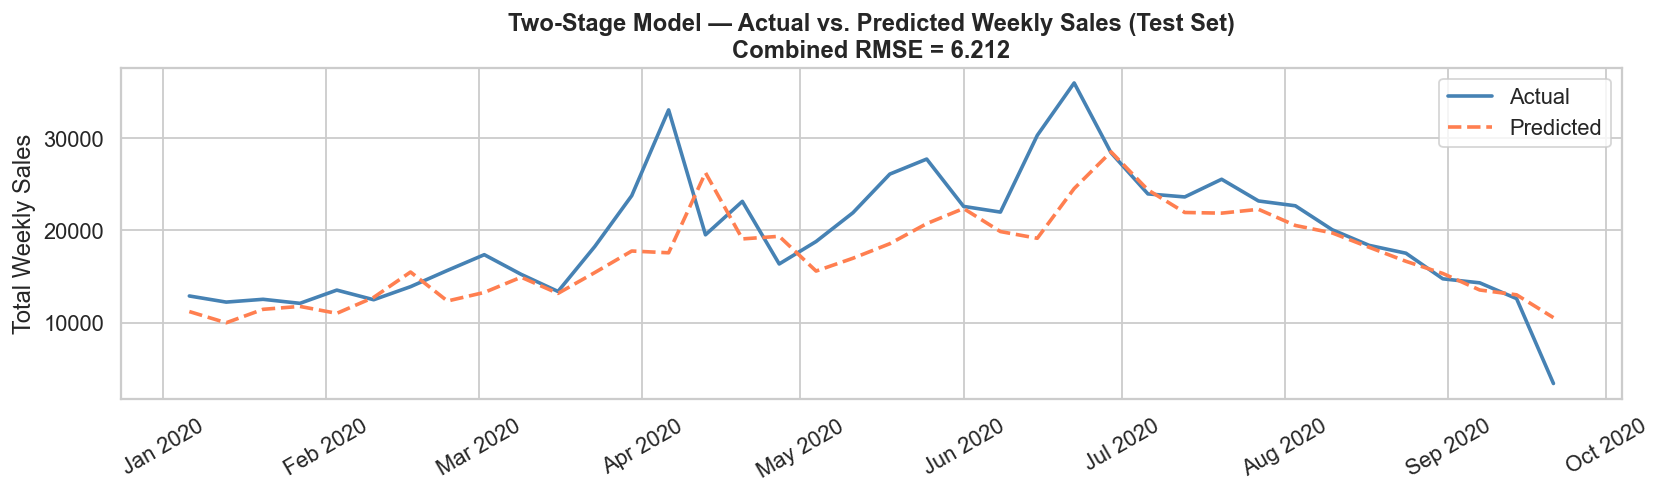

Saved: plots/zero_sales/approach2_two_stage_predictions.png


In [11]:
# ── Combined two-stage prediction on full test set ────────────────────────────

test_b['stage1_pred'] = test_pred_cls
test_b['stage2_pred'] = 0.0

# Only predict quantity where stage 1 says demand > 0
demand_mask = test_b['stage1_pred'] == 1
if demand_mask.sum() > 0:
    preds_log = reg.predict(test_b.loc[demand_mask, REGRESSOR_FEATURES])
    test_b.loc[demand_mask, 'stage2_pred'] = np.expm1(np.clip(preds_log, 0, None))

combined_rmse = rmse(test_b['weekly_sales_volume'], test_b['stage2_pred'])
print(f'Two-stage combined RMSE (full test set, original scale): {combined_rmse:.4f}')
print(f'  (includes zeros predicted by stage 1 classifier)')

# Weekly aggregation
weekly = test_b.groupby('week_start').agg(
    actual=('weekly_sales_volume', 'sum'),
    predicted=('stage2_pred', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(weekly['week_start'], weekly['actual'],    label='Actual',    color='steelblue', linewidth=2)
ax.plot(weekly['week_start'], weekly['predicted'], label='Predicted', color='coral', linewidth=2, linestyle='--')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=30)
ax.set_title(f'Two-Stage Model — Actual vs. Predicted Weekly Sales (Test Set)\n'
             f'Combined RMSE = {combined_rmse:.3f}', fontweight='bold')
ax.set_ylabel('Total Weekly Sales')
ax.legend()
plt.tight_layout()
plt.savefig('plots/zero_sales/approach2_two_stage_predictions.png')
plt.show()
print('Saved: plots/zero_sales/approach2_two_stage_predictions.png')

In [12]:
# ── Save binary dataset with occurrence features ──────────────────────────────
df_binary.to_csv(f'{BASE}/tshirts_binary.csv', index=False)

train_b_out = df_binary[df_binary['week_start'] <= TRAIN_END].copy()
val_b_out   = df_binary[(df_binary['week_start'] > TRAIN_END) & (df_binary['week_start'] <= VAL_END)].copy()
test_b_out  = df_binary[df_binary['week_start'] > VAL_END].copy()

train_b_out.to_csv(f'{BASE}/tshirts_binary_train.csv', index=False)
val_b_out.to_csv(f'{BASE}/tshirts_binary_val.csv',     index=False)
test_b_out.to_csv(f'{BASE}/tshirts_binary_test.csv',   index=False)
print(f'Saved binary splits:  train={len(train_b_out):,}  val={len(val_b_out):,}  test={len(test_b_out):,}')

Saved binary splits:  train=259,809  val=275,555  test=299,174


In [13]:
# ── Summary comparison ────────────────────────────────────────────────────────
print('=' * 65)
print('ZERO SALES HANDLING — APPROACH COMPARISON')
print('=' * 65)
print()
print('Approach 1 — Even Spreading')
print('  - Replaces intermittent zeros with smoothed monthly averages')
print('  - Target: continuous, fewer exact zeros')
print('  - Use with: standard single-stage regression (models.ipynb)')
print('  - Saved to: tshirts_spread_train/val/test.csv')
print()
print('Approach 2 — Binary Demand Occurrence (0/1)')
print('  - Adds demand_occurred, demand_lag1, demand_rolling4_pct features')
print('  - Stage 1: classify if sales > 0 (LightGBM classifier)')
print('  - Stage 2: predict quantity for positive-demand weeks only')
print(f'  - Two-stage combined RMSE (test): {combined_rmse:.4f}')
print('  - Saved to: tshirts_binary_train/val/test.csv')
print()
print('Recommendation:')
print('  Compare both against baseline (tshirts_train/val/test.csv) in models.ipynb.')
print('  Binary features can also be used as extra features in single-stage models.')

ZERO SALES HANDLING — APPROACH COMPARISON

Approach 1 — Even Spreading
  - Replaces intermittent zeros with smoothed monthly averages
  - Target: continuous, fewer exact zeros
  - Use with: standard single-stage regression (models.ipynb)
  - Saved to: tshirts_spread_train/val/test.csv

Approach 2 — Binary Demand Occurrence (0/1)
  - Adds demand_occurred, demand_lag1, demand_rolling4_pct features
  - Stage 1: classify if sales > 0 (LightGBM classifier)
  - Stage 2: predict quantity for positive-demand weeks only
  - Two-stage combined RMSE (test): 6.2117
  - Saved to: tshirts_binary_train/val/test.csv

Recommendation:
  Compare both against baseline (tshirts_train/val/test.csv) in models.ipynb.
  Binary features can also be used as extra features in single-stage models.
